# Домашнее задание к занятию «Feature Select»

Выполнил: Ярослав Золотухин

## Генерация данных и рассчет средней точности логистической регрессии

In [1]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
x_data_generated, y_data_generated = make_classification(scale=1)
acc = cross_val_score(LogisticRegression(), x_data_generated, y_data_generated, scoring='accuracy').mean()
print(acc)

0.9099999999999999


## Статистические методы для отбора признаков

Выбираем признаки на основе матрицы корреляции.

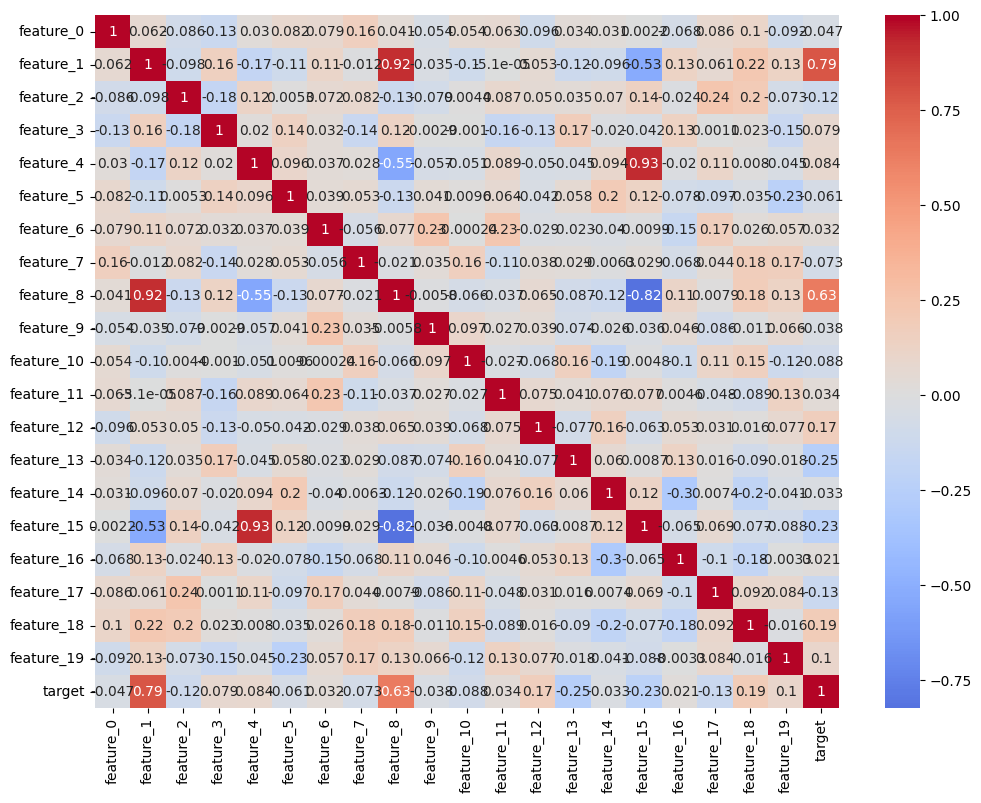

In [7]:
df_features = pd.DataFrame(x_data_generated, columns=[f'feature_{i}' for i in range(x_data_generated.shape[1])])
df_generated = df_features.copy()
df_generated['target'] = y_data_generated

corr = df_generated.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.show()

Тепловая карта показывает, что между есть сильные связи между: 

- feature_15 и feature_4
- feature_15 и feature_8
- feature_8 и feature_1

Уберем из выборки признаки feature_8 и feature_15, из-за их меньшей связи с целевой переменной.

In [10]:
cols_to_drop = ["feature_8", "feature_15", "target"]
df_del_col = df_generated.drop(columns=cols_to_drop)
acc_del_col = cross_val_score(LogisticRegression(), df_del_col, df_generated['target'], scoring='accuracy').mean()
print(acc_del_col)

0.9099999999999999


Точность осталась прежней.

In [11]:
from sklearn.metrics import mutual_info_score

for col in df_generated[:-1]:
    print('target -', col, mutual_info_score(df_generated[col], df_generated['target']))

target - feature_0 0.6931471805599458
target - feature_1 0.6931471805599458
target - feature_2 0.6931471805599458
target - feature_3 0.6931471805599458
target - feature_4 0.6931471805599458
target - feature_5 0.6931471805599458
target - feature_6 0.6931471805599458
target - feature_7 0.6931471805599458
target - feature_8 0.6931471805599458
target - feature_9 0.6931471805599458
target - feature_10 0.6931471805599458
target - feature_11 0.6931471805599458
target - feature_12 0.6931471805599458
target - feature_13 0.6931471805599458
target - feature_14 0.6931471805599458
target - feature_15 0.6931471805599458
target - feature_16 0.6931471805599458
target - feature_17 0.6931471805599458
target - feature_18 0.6931471805599458
target - feature_19 0.6931471805599458
target - target 0.6931471805599458


/Users/acer/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/Users/acer/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/Users/acer/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/Users/acer/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for t

Признаки показали идентичный mutual_info_score. Связано это с тем, что данные сгенерированы, при генерации дополнительный шум не был задан.

### Удалим признаки, которые имеют низкую вариантивность. Значение порога возьмем 80%

In [12]:
df_features.var().sort_values()

feature_14    0.757937
feature_9     0.762311
feature_5     0.820152
feature_3     0.848864
feature_8     0.850243
feature_16    0.853054
feature_6     0.945585
feature_11    0.950320
feature_2     0.993098
feature_12    0.998706
feature_17    1.011192
feature_10    1.043439
feature_7     1.059105
feature_19    1.068256
feature_0     1.131270
feature_13    1.142357
feature_18    1.263550
feature_1     1.348072
feature_15    1.391493
feature_4     1.645084
dtype: float64

In [14]:
from sklearn.feature_selection import VarianceThreshold


sel = VarianceThreshold(threshold=0.8)
x_data_selected = sel.fit_transform(df_features)
x_data_selected.shape

(100, 18)

Было исключено два признака. Рассчитаем точность логистической модели после преобразований.

In [15]:
acc_2 = cross_val_score(LogisticRegression(), x_data_selected, y_data_generated, scoring='accuracy').mean()
print(acc_2)

0.9199999999999999


Точность стала выше.

## Отбор признаков на основе дисперсионного анализа

In [16]:
from sklearn.feature_selection import SelectKBest
X_new = SelectKBest(k=5).fit_transform(x_data_generated, y_data_generated)
acc_3 = cross_val_score(LogisticRegression(), X_new, y_data_generated, scoring='accuracy').mean()
print(X_new.shape)
print(acc_3)

(100, 5)
0.9399999999999998


Точность улучшена

## Отбор с использованием моделей

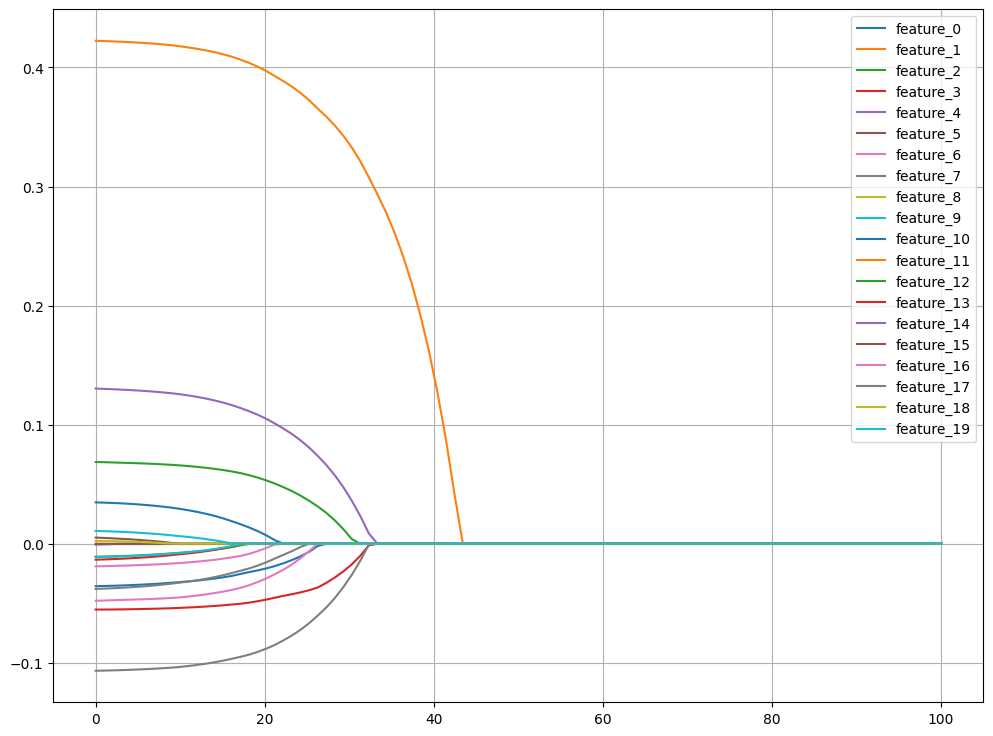

In [23]:
from sklearn.linear_model import Lasso # линейная модель с L1-регуляризацией
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')
X_sc = StandardScaler().fit_transform(x_data_generated) # преобразование данных
lg_l,pred_l = [], []

list_l = list(2**np.linspace(-10,10,100))
feature_names = df_generated.drop(columns=["target"]).columns.tolist()
# строим n-ое кол-во моделей Лассо, меняя коэффициент регуляризации, сохраняя модель и коэффициенты
for i in range(len(list_l)):
    m_l = Lasso(alpha=list_l[i]).fit(X_sc, y_data_generated)
    lg_l.append(m_l)
    pred_l.append(m_l.coef_)

# рисуем отмасштабированные признаки на одном графике
plt.figure(figsize=(12,9))
x_l = np.linspace(0,len(pred_l),len(pred_l))
for i in np.vstack(pred_l).T:
    plt.plot(x_l,np.sign(i)*np.abs(i))
      
plt.legend(feature_names)   
plt.grid()

Признак feature_1 зануляется медленнее всего, т.к. он имеет сильную связь с целевой переменной. feature_1, feature_4 также занулялись менее остальных.

In [24]:
from sklearn.feature_selection import SelectFromModel

logReg = LogisticRegression(random_state=1).fit(x_data_generated, y_data_generated)
selector = SelectFromModel(logReg, prefit=False, max_features=5, threshold=-np.inf)
X_tr = selector.fit_transform(x_data_generated, y_data_generated)
acc_4 = cross_val_score(LogisticRegression(), X_tr, y_data_generated, scoring='accuracy').mean()
print(X_tr.shape)
print(acc_4)

(100, 5)
0.96


Точность показала хороший результат.

In [18]:
from sklearn.ensemble import RandomForestClassifier


model_rf = RandomForestClassifier(random_state=1)
model_rf.fit(x_data_generated, y_data_generated) # обучение

importances = model_rf.feature_importances_

# выберем 5 самых важных признаков
top_features = np.argsort(importances)[-5:]

x_data_rf_selected = x_data_generated[:, top_features]

acc_5 = cross_val_score(LogisticRegression(), x_data_rf_selected, y_data_generated, scoring='accuracy').mean()
print(x_data_rf_selected.shape)
print(acc_5)


(100, 5)
0.96


Точность на показала хороший результат, но не лучше чем при отборе на основе моделей.

## Перебор признаков

In [19]:
from sklearn.feature_selection import SequentialFeatureSelector


sfs_backward = SequentialFeatureSelector(
    LogisticRegression(random_state=1), direction="backward"
)
sfs_backward.fit(x_data_generated, y_data_generated)
X_tr_seq = sfs_backward.transform(x_data_generated)
acc_6 = cross_val_score(LogisticRegression(), X_tr_seq, y_data_generated, scoring='accuracy').mean()
print(X_tr_seq.shape)
print(acc_6)

(100, 10)
0.99


Сведем полученные результаты в таблицу.

In [25]:
results = pd.DataFrame({
    'Метод': [
        'Без отбора признаков',
        'Матрица корреляции',
        'VarianceThreshold',
        'SelectKBest',
        'SelectFromModel',
        'RandomForest feature_importances',
        'SequentialFeatureSelector'
    ],
    'Количество признаков': [
        x_data_generated.shape[1],
        df_del_col.shape[1],
        x_data_selected.shape[1],
        X_new.shape[1],
        X_tr.shape[1],
        x_data_rf_selected.shape[1],
        X_tr_seq.shape[1]
    ],
    'Accuracy': [
        acc,
        acc_del_col,
        acc_2,
        acc_3,
        acc_4,
        acc_5,
        acc_6
    ]
})

results['Accuracy'] = results['Accuracy'].round(4)
results

,Метод,Количество признаков,Accuracy
0,Без отбора признаков,20,0.91
1,Матрица корреляции,18,0.91
2,VarianceThreshold,18,0.92
3,SelectKBest,5,0.94
4,SelectFromModel,5,0.96
5,RandomForest feature_importances,5,0.96
6,SequentialFeatureSelector,10,0.99


# Вывод

В ходе данного домашнего задания были рассмотрены различные варианты методов отбора признаков. Перебор признаков для лучший результат, но на практических данных он может занять продолжительное время выполнения.

Также хороший результат продемонстрировали методы отбора на основе моделей.